In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
 
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
  
from sklearn.preprocessing import PowerTransformer

In [2]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [3]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [4]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [5]:
# Check null values in D2 
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [6]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [7]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [13]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [14]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [15]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [16]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Yeo-Johnson Transformation for Clustering

In [17]:
original_X = X.copy()

In [18]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']
### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical using the min max scaling
pt = PowerTransformer(method='yeo-johnson')
X_numeric_std = pt.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

# Clustering

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

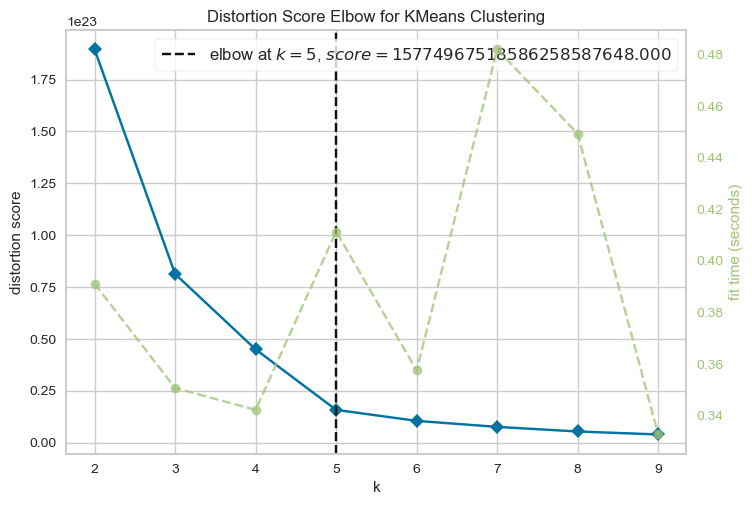

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [19]:
# Decide how many clusters to form 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

### Using the highest feature importance

In [20]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    coxph = CoxPHFitter(penalizer=0.00001)
    X_cluster = X_std[X_std.columns[cluster_labels==i]]
    X_cluster = pd.concat([X_cluster, clinical_train[['DFS', 'event_DFS']]], axis=1)
    coxph.fit(X_cluster, duration_col='DFS', event_col='event_DFS')

    # Get coefficients and associated feature names
    coefficients = coxph.summary['coef']
    feature_names = coxph.summary.index

    # Create a DataFrame to store coefficients and feature names
    coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

    # Take absolute values of coefficients
    coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

    # Sort coefficients by absolute value to identify important features
    sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)

    # Display the column with the highest feature importance and its coefficient value
    max_coefficient_feature = sorted_coefficients_df.loc[sorted_coefficients_df['Abs_Coefficient'].idxmax()]
    print(f"Cluster {i}: Most important feature: {max_coefficient_feature['Feature']}, Coefficient: {max_coefficient_feature['Coefficient']}")
    selected_features.append(max_coefficient_feature['Feature'])
  

KMeans(n_clusters=5)

<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 0: Most important feature: first_order_90Percentile_PET, Coefficient: 3.4229119297966104


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 1: Most important feature: glcm_DifferenceAverage_d_1_PET_c04, Coefficient: 4.096477008598892


...

Cluster 2: Most important feature: first_order_90Percentile_CT, Coefficient: -154525957354209.66


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 3: Most important feature: glcm_Autocorrelation_d_1_CT_b20, Coefficient: 1.532476577313396


<lifelines.CoxPHFitter: fitted with 139 total observations, 71 right-censored observations>

Cluster 4: Most important feature: gldm_LargeDependenceEmphasis_d_1_CT_b20, Coefficient: -3.7210938297536273


In [21]:
# Selecting features in the DataFrame
X_fs_fi = X[selected_features]
X_new = X_fs_fi.copy()

X_MAASTRO_fs_fi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_fi.copy()

# Yeo-Johnson Transformation

In [22]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new_std = MAASTRO_new_std[MAASTRO_new.columns]

In [23]:
X_new

,first_order_90Percentile_PET,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_Autocorrelation_d_1_CT_b20,gldm_LargeDependenceEmphasis_d_1_CT_b20
0,12.976912,0.356587,1177.917830,2024.127331,113.386086
1,5.631130,0.420129,1109.046098,1273.080749,125.347887
2,6.963644,0.325835,1149.884925,2688.489673,141.882473
3,2.937064,0.401664,1126.003305,2081.055438,58.724303
4,5.652872,0.510112,1134.384047,1795.967423,63.973695
...,...,...,...,...,...
134,8.774738,0.409956,1157.360037,846.398938,145.946280
135,6.606596,0.321183,1126.367132,1640.501203,246.931740
136,12.128900,0.374487,1111.612526,1564.244432,211.522778
137,7.277164,0.402135,1117.834717,1055.251277,277.199566


In [24]:
X_new_std

,first_order_90Percentile_PET,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_Autocorrelation_d_1_CT_b20,gldm_LargeDependenceEmphasis_d_1_CT_b20
0,0.751505,-0.094031,8.604228e-16,0.004049,-1.179068
1,-0.983140,0.595643,-3.885781e-16,-0.950629,-0.989913
2,-0.580723,-0.468257,3.885781e-16,0.932669,-0.735003
3,-2.051604,0.405940,-5.551115e-17,0.080834,-2.113912
4,-0.976074,1.412495,1.110223e-16,-0.297894,-2.017501
...,...,...,...,...,...
134,-0.112625,0.492151,5.273559e-16,-1.433696,-0.673405
135,-0.682915,-0.527421,-5.551115e-17,-0.497999,0.757715
136,0.595777,0.111075,-3.330669e-16,-0.594371,0.274529
137,-0.493971,0.410886,-2.220446e-16,-1.203675,1.158353


In [25]:
MAASTRO_new

,first_order_90Percentile_PET,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_Autocorrelation_d_1_CT_b20,gldm_LargeDependenceEmphasis_d_1_CT_b20
0,14.076383,0.335443,1103.940398,1491.330500,309.851161
1,7.077812,0.279434,1117.575395,2979.095303,186.233062
2,11.123887,0.310763,1110.775817,1991.788394,243.995021
3,7.374829,0.301684,1191.267456,3019.885590,100.998881
4,8.358805,0.300615,1108.918120,2202.694259,288.723635
...,...,...,...,...,...
94,28.833381,0.327473,1132.303273,1982.818842,197.510532
95,11.134466,0.310449,1108.789902,2668.843896,168.151035
96,7.233497,0.264803,1107.996338,2863.172225,242.846835
97,11.935536,0.305581,1161.546578,2064.421825,145.524084


In [26]:
MAASTRO_new_std

,first_order_90Percentile_PET,glcm_DifferenceAverage_d_1_PET_c04,first_order_90Percentile_CT,glcm_Autocorrelation_d_1_CT_b20,gldm_LargeDependenceEmphasis_d_1_CT_b20
0,0.942522,-0.348239,-5.273559e-16,-0.685370,1.579571
1,-0.548821,-1.090997,-2.220446e-16,1.359302,-0.081821
2,0.400423,-0.662484,-3.608225e-16,-0.039319,0.718268
3,-0.467485,-0.783134,1.082467e-15,1.420092,-1.379769
4,-0.213562,-0.797524,-3.885781e-16,0.246746,1.308240
...,...,...,...,...,...
94,2.800745,-0.447593,8.326673e-17,-0.051315,0.078359
95,0.402545,-0.666615,-4.163336e-16,0.904249,-0.343338
96,-0.505894,-1.303381,-4.163336e-16,1.187741,0.702816
97,0.559145,-0.731004,6.106227e-16,0.058341,-0.679786


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [27]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 20:36:27,280] A new study created in memory with name: no-name-b0e9972b-d680-4e24-9307-482b85ef4d10
python(32486) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.44621513944223107
Fold 2 C-index: 0.5968992248062015
Fold 3 C-index: 0.574468085106383


[I 2024-04-16 20:36:28,093] A new study created in memory with name: no-name-04498b92-f353-4a86-980a-a6a644f92084


Fold 4 C-index: 0.5475285171102662
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 20:36:28,056] Trial 0 finished with value: 0.5197174722629734 and parameters: {}. Best is trial 0 with value: 0.5197174722629734.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5197174722629734], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 27, 510267), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 28, 54662), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5197174722629734


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2715968925917433
Fold 2 IBS: 0.22011354361847982
Fold 3 IBS: 0.22884949461319326
Fold 4 IBS: 0.2616784508427125
Fold 5 IBS: 0.25233721809055687
[I 2024-04-16 20:36:28,738] Trial 0 finished with value: 0.24691511995133714 and parameters: {}. Best is trial 0 with value: 0.24691511995133714.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24691511995133714], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 28, 204089), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 28, 738445), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24691511995133714


In [28]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [29]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.52
train_ibs:  0.247


#### Test

In [30]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [31]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.515
IBS score: 0.243


In [32]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [33]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [34]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 20:36:29,052] A new study created in memory with name: no-name-804359bc-8ae5-48f7-a522-0bb311be515f


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.448207171314741
Fold 2 C-index: 0.6782945736434108
Fold 3 C-index: 0.5085106382978724
Fold 4 C-index: 0.5817490494296578


[I 2024-04-16 20:36:29,481] A new study created in memory with name: no-name-982740ac-3a8b-470e-8d0c-1b2ebe0291c2


Fold 5 C-index: 0.44420600858369097
[I 2024-04-16 20:36:29,466] Trial 0 finished with value: 0.5321934882538746 and parameters: {}. Best is trial 0 with value: 0.5321934882538746.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5321934882538746], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 29, 145325), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 29, 465748), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5321934882538746


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724710010039816
Fold 2 IBS: 0.23203987544546026
Fold 3 IBS: 0.22898186666012907
Fold 4 IBS: 0.24197477070602932
Fold 5 IBS: 0.2293955948729073
[I 2024-04-16 20:36:30,107] Trial 0 finished with value: 0.23592784155698485 and parameters: {}. Best is trial 0 with value: 0.23592784155698485.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592784155698485], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 29, 530410), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 30, 106685), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592784155698485


In [35]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [36]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.532
train_ibs:  0.236


#### Test

In [37]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [38]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.514


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [39]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [40]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 20:36:30,388] A new study created in memory with name: no-name-bdbe75e5-e319-4aff-8937-3e471f4825b8


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943


[I 2024-04-16 20:36:30,882] A new study created in memory with name: no-name-839b58ef-d6d1-44f8-a950-0dfa17be2d5b


Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:30,867] Trial 0 finished with value: 0.5397954993811617 and parameters: {}. Best is trial 0 with value: 0.5397954993811617.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.5397954993811617], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 30, 443169), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 30, 867327), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.5397954993811617


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.26323561787758415
Fold 2 IBS: 0.2224482157026049
Fold 3 IBS: 0.22820854275850636
Fold 4 IBS: 0.24180986492972492
Fold 5 IBS: 0.24833994616367405
[I 2024-04-16 20:36:31,301] Trial 0 finished with value: 0.24080843748641886 and parameters: {}. Best is trial 0 with value: 0.24080843748641886.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.24080843748641886], datetime_start=datetime.datetime(2024, 4, 16, 20, 36, 30, 943183), datetime_complete=datetime.datetime(2024, 4, 16, 20, 36, 31, 300939), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.24080843748641886


In [41]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [42]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.54
train_ibs:  0.241


#### Test

In [43]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [44]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.506


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.23


In [45]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [46]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 20:36:31,749] A new study created in memory with name: no-name-3173fd64-8874-4270-a0c7-db67ef413818


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:32,222] Trial 0 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:32,514] Trial 1 finished with value: 0.5389444355513745 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5063829787234042
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:32,934] Trial 2 finished with value: 0.5389444355513745 and parameters: {'l1_ratio': 0.22692876841884668}. Be

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:41,906] Trial 24 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.7602371709740536}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:42,223] Trial 25 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.891573855041803}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:42,573] Trial 26 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.4514399534035586}. Be

Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:55,686] Trial 48 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.5033132688848968}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:56,130] Trial 49 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.355745098499332}. Best is trial 0 with value: 0.5397954993811617.
Fold 1 C-index: 0.44223107569721115
Fold 2 C-index: 0.689922480620155
Fold 3 C-index: 0.5106382978723404
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4592274678111588
[I 2024-04-16 20:36:56,798] Trial 50 finished with value: 0.5397954993811617 and parameters: {'l1_ratio': 0.8449632453631055}. Be

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.26324199847788293
Fold 2 IBS: 0.22287150465285935
Fold 3 IBS: 0.2282031944567597
Fold 4 IBS: 0.2417414746697589
Fold 5 IBS: 0.24829891161002185
[I 2024-04-16 20:37:15,839] Trial 0 finished with value: 0.24087141677345655 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.24087141677345655.
Fold 1 IBS: 0.2631876354492412
Fold 2 IBS: 0.22445165557819474
Fold 3 IBS: 0.22822662625881515
Fold 4 IBS: 0.2416057782773714
Fold 5 IBS: 0.24823686742942727
[I 2024-04-16 20:37:16,562] Trial 1 finished with value: 0.24114171259860995 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.24087141677345655.
Fold 1 IBS: 0.2631700849931153
Fold 2 IBS: 0.22499003555311908
Fold 3 IBS: 0.22824768819371483
Fold 4 IBS: 0.24159132390731167
Fold 5 IBS: 0.24823181907194025
[I 2024-04-16 20:37:17,467] Trial 2 finished with value: 0.24124619034384023 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.24087141677345

Fold 1 IBS: 0.26316625900448853
Fold 2 IBS: 0.22413251618079885
Fold 3 IBS: 0.22821672932643652
Fold 4 IBS: 0.24162082736347815
Fold 5 IBS: 0.24827637988703213
[I 2024-04-16 20:37:26,062] Trial 25 finished with value: 0.24108254235244683 and parameters: {'l1_ratio': 0.3320370850172741}. Best is trial 19 with value: 0.23498033817593916.
Fold 1 IBS: 0.2473777087418365
Fold 2 IBS: 0.22660513902494506
Fold 3 IBS: 0.22834544624277525
Fold 4 IBS: 0.24160990651647127
Fold 5 IBS: 0.23122640713734954
[I 2024-04-16 20:37:26,288] Trial 26 finished with value: 0.2350329215326755 and parameters: {'l1_ratio': 0.12146728593018874}. Best is trial 19 with value: 0.23498033817593916.
Fold 1 IBS: 0.263180473142866
Fold 2 IBS: 0.22493043471566848
Fold 3 IBS: 0.22824505254735442
Fold 4 IBS: 0.24159231046627003
Fold 5 IBS: 0.24823933255344655
[I 2024-04-16 20:37:26,596] Trial 27 finished with value: 0.24123752068512108 and parameters: {'l1_ratio': 0.23262294219837004}. Best is trial 19 with value: 0.2349803

Fold 2 IBS: 0.22843635323026895
Fold 3 IBS: 0.22851110160588595
Fold 4 IBS: 0.24170164261765925
Fold 5 IBS: 0.23038692180805295
[I 2024-04-16 20:37:32,764] Trial 50 finished with value: 0.23525133571395657 and parameters: {'l1_ratio': 0.05978405253459762}. Best is trial 35 with value: 0.23497676233958137.
Fold 1 IBS: 0.2631542458212147
Fold 2 IBS: 0.22507912847742279
Fold 3 IBS: 0.22825176507561157
Fold 4 IBS: 0.24159011320483711
Fold 5 IBS: 0.23226342733988792
[I 2024-04-16 20:37:33,041] Trial 51 finished with value: 0.23806773598379483 and parameters: {'l1_ratio': 0.21875305902928327}. Best is trial 35 with value: 0.23497676233958137.
Fold 1 IBS: 0.2473479105674746
Fold 2 IBS: 0.22682581287680378
Fold 3 IBS: 0.22836248627880337
Fold 4 IBS: 0.24161785539173417
Fold 5 IBS: 0.23110627824579255
[I 2024-04-16 20:37:33,263] Trial 52 finished with value: 0.23505206867212172 and parameters: {'l1_ratio': 0.11185917521958509}. Best is trial 35 with value: 0.23497676233958137.
Fold 1 IBS: 0.263

Fold 1 IBS: 0.24745778117775222
Fold 2 IBS: 0.22611726091518083
Fold 3 IBS: 0.22831079756588316
Fold 4 IBS: 0.24159632048019974
Fold 5 IBS: 0.23151551224014214
[I 2024-04-16 20:37:41,144] Trial 75 finished with value: 0.23499953447583163 and parameters: {'l1_ratio': 0.1458455734339822}. Best is trial 54 with value: 0.23497674012613778.
Fold 1 IBS: 0.2631610167326382
Fold 2 IBS: 0.22460802258378615
Fold 3 IBS: 0.2282320971572634
Fold 4 IBS: 0.241600245364946
Fold 5 IBS: 0.24827562497941405
[I 2024-04-16 20:37:41,662] Trial 76 finished with value: 0.24117540136360954 and parameters: {'l1_ratio': 0.26699688802977506}. Best is trial 54 with value: 0.23497674012613778.
Fold 1 IBS: 0.26319819604604083
Fold 2 IBS: 0.22393880045819553
Fold 3 IBS: 0.22821204973848566
Fold 4 IBS: 0.24163262682542805
Fold 5 IBS: 0.24829747021995513
[I 2024-04-16 20:37:41,970] Trial 77 finished with value: 0.24105582865762104 and parameters: {'l1_ratio': 0.3652839852544478}. Best is trial 54 with value: 0.23497674

In [47]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [48]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.54
train_ibs:  0.235


#### Test

In [49]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [50]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.6964995386793018)

test_cindex : 0.507


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.19782149798513768)

test_ibs:  0.229


In [51]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [52]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 20:37:48,167] A new study created in memory with name: no-name-6ea16d4c-4a4c-467d-8114-e455a56a04ee


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5039840637450199
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.46382978723404256
Fold 4 C-index: 0.5779467680608364
Fold 5 C-index: 0.47639484978540775
[I 2024-04-16 20:37:51,763] Trial 0 finished with value: 0.5245861325247513 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.5245861325247513.
Fold 1 C-index: 0.5219123505976095
Fold 2 C-index: 0.5930232558139535
Fold 3 C-index: 0.4595744680851064
Fold 4 C-index: 0.5855513307984791
Fold 5 C-index: 0.463519313304721
[I 2024-04-16 20:37:54,450] Trial 1 finished with value: 0.524716143719974 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 

Fold 5 C-index: 0.5686695278969958
[I 2024-04-16 20:38:24,706] Trial 15 finished with value: 0.6126515040625111 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 7, 'min_samples_leaf': 15, 'max_depth': 1, 'n_estimators': 79, 'oob_score': True, 'max_samples': 0.817309431417591, 'max_features': None, 'min_weight_fraction_leaf': 0.20663398741831335, 'warm_start': True}. Best is trial 14 with value: 0.6392662920007164.
Fold 1 C-index: 0.5677290836653387
Fold 2 C-index: 0.7189922480620154
Fold 3 C-index: 0.7127659574468085
Fold 4 C-index: 0.6254752851711026
Fold 5 C-index: 0.6008583690987125
[I 2024-04-16 20:38:24,858] Trial 16 finished with value: 0.6451641886887955 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 5, 'oob_score': True, 'max_samples': 0.8031281433915335, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3792168673484642, 'warm_start': True}. Best is trial 16 with value: 0.6451641886887955.
Fo

Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.6851063829787234
Fold 4 C-index: 0.6349809885931559
Fold 5 C-index: 0.6437768240343348
[I 2024-04-16 20:38:33,447] Trial 31 finished with value: 0.639769349204939 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 2, 'max_depth': 1, 'n_estimators': 106, 'oob_score': True, 'max_samples': 0.8723829147590596, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1971978552965416, 'warm_start': True}. Best is trial 16 with value: 0.6451641886887955.
Fold 1 C-index: 0.5179282868525896
Fold 2 C-index: 0.7248062015503876
Fold 3 C-index: 0.7191489361702128
Fold 4 C-index: 0.688212927756654
Fold 5 C-index: 0.703862660944206
[I 2024-04-16 20:38:33,846] Trial 32 finished with value: 0.67079180265481 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 2, 'max_depth': 2, 'n_estimators': 67, 'oob_score': True, 'max_samples': 0.9133276626620687, 'max_f

...

Fold 5 IBS: 0.23425600293360294
[I 2024-04-16 20:42:06,870] Trial 31 finished with value: 0.23018641136765555 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 8, 'min_samples_leaf': 8, 'max_depth': 20, 'n_estimators': 438, 'oob_score': True, 'max_samples': 0.9806680545887495, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.4375231110327068}. Best is trial 31 with value: 0.23018641136765555.
Fold 1 IBS: 0.2462910761735419
Fold 2 IBS: 0.23213041520029323
Fold 3 IBS: 0.22956204890513934
Fold 4 IBS: 0.24154193679997377
Fold 5 IBS: 0.2331142273522301
[I 2024-04-16 20:42:12,376] Trial 32 finished with value: 0.2365279408862357 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 8, 'min_samples_leaf': 6, 'max_depth': 20, 'n_estimators': 455, 'oob_score': True, 'max_samples': 0.9307510052900211, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.4601759103612191}. Best is trial 31 with value: 0.23018641136765555.
Fold 1 IBS: 0.24633658245141082
Fold 2 IBS: 0.232177167

Fold 1 IBS: 0.23996500279359728
Fold 2 IBS: 0.21881407781188492
Fold 3 IBS: 0.22460202475874547
Fold 4 IBS: 0.23826685696339198
Fold 5 IBS: 0.23580703458089738
[I 2024-04-16 20:43:24,211] Trial 47 finished with value: 0.23149099938170342 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 13, 'min_samples_leaf': 9, 'max_depth': 17, 'n_estimators': 430, 'oob_score': True, 'max_samples': 0.9461651576703607, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.3665503362062834}. Best is trial 31 with value: 0.23018641136765555.
Fold 1 IBS: 0.2464137402906637
Fold 2 IBS: 0.23216401829087477
Fold 3 IBS: 0.22955963441660382
Fold 4 IBS: 0.2414825500682737
Fold 5 IBS: 0.2302190244606397
[I 2024-04-16 20:43:28,433] Trial 48 finished with value: 0.2359677935054111 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 14, 'min_samples_leaf': 7, 'max_depth': 19, 'n_estimators': 366, 'oob_score': True, 'max_samples': 0.7958858370661757, 'max_features': 'sqrt', 'min_weight_fraction_le

Fold 1 IBS: 0.2464325831297087
Fold 2 IBS: 0.23215940344034322
Fold 3 IBS: 0.2295791303183512
Fold 4 IBS: 0.2414968665414514
Fold 5 IBS: 0.23029230995113273
[I 2024-04-16 20:45:06,208] Trial 63 finished with value: 0.23599205867619744 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 5, 'min_samples_leaf': 3, 'max_depth': 13, 'n_estimators': 352, 'oob_score': True, 'max_samples': 0.895211407955079, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.48189951104598916}. Best is trial 57 with value: 0.22996410214738305.
Fold 1 IBS: 0.24102241451843326
Fold 2 IBS: 0.2160706825517434
Fold 3 IBS: 0.22014865621978344
Fold 4 IBS: 0.23782070975711325
Fold 5 IBS: 0.233606610782064
[I 2024-04-16 20:45:11,166] Trial 64 finished with value: 0.22973381476582744 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 4, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 232, 'oob_score': True, 'max_samples': 0.9782113745450898, 'max_features': 'auto', 'min_weight_fraction_leaf': 0

Fold 1 IBS: 0.24066441980528605
Fold 2 IBS: 0.21578173608104415
Fold 3 IBS: 0.22127951984008135
Fold 4 IBS: 0.23836223469855272
Fold 5 IBS: 0.23408647011986933
[I 2024-04-16 20:46:17,348] Trial 79 finished with value: 0.2300348761089667 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 3, 'max_depth': 15, 'n_estimators': 317, 'oob_score': True, 'max_samples': 0.9344558097701683, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.4432652910478053}. Best is trial 64 with value: 0.22973381476582744.
Fold 1 IBS: 0.2465465295816866
Fold 2 IBS: 0.2321748020188175
Fold 3 IBS: 0.22957330361178122
Fold 4 IBS: 0.2414882251271943
Fold 5 IBS: 0.23029821767753422
[I 2024-04-16 20:46:21,919] Trial 80 finished with value: 0.23601621560340275 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 14, 'n_estimators': 304, 'oob_score': True, 'max_samples': 0.7486426002367315, 'max_features': 'auto', 'min_weight_fraction_leaf':

Fold 1 IBS: 0.24022137140853417
Fold 2 IBS: 0.2163552305739269
Fold 3 IBS: 0.22161715949310634
Fold 4 IBS: 0.23683265072531925
Fold 5 IBS: 0.23272534782455795
[I 2024-04-16 20:47:21,580] Trial 95 finished with value: 0.22955035200508891 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 4, 'min_samples_leaf': 19, 'max_depth': 14, 'n_estimators': 172, 'oob_score': True, 'max_samples': 0.9479621869395501, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.4302569670316735}. Best is trial 94 with value: 0.22954501542512853.
Fold 1 IBS: 0.2399797494814549
Fold 2 IBS: 0.21705455052719952
Fold 3 IBS: 0.22147417026691804
Fold 4 IBS: 0.2387898759520708
Fold 5 IBS: 0.2330144156220401
[I 2024-04-16 20:47:23,981] Trial 96 finished with value: 0.23006255236993667 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 20, 'max_depth': 14, 'n_estimators': 169, 'oob_score': True, 'max_samples': 0.8703994765174918, 'max_features': 'auto', 'min_weight_fraction_leaf

In [53]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [54]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.793
train_ibs:  0.23


#### Test

In [55]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [56]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=11, max_features='auto', max_leaf_nodes=19,
                     max_samples=0.7269933477702389, min_samples_leaf=1,
                     min_samples_split=9,
                     min_weight_fraction_leaf=0.026581048952818185,
                     n_estimators=285, random_state=123, warm_start=True)

test_cindex:  0.539


RandomSurvivalForest(max_depth=13, max_features='auto', max_leaf_nodes=4,
                     max_samples=0.9116735193426042, min_samples_leaf=18,
                     min_samples_split=3,
                     min_weight_fraction_leaf=0.42699846201781244,
                     n_estimators=174, oob_score=True, random_state=123)

test_ibs:  0.23


In [57]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [58]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 20:47:30,838] A new study created in memory with name: no-name-1e941289-2633-4a7d-a380-cbaa8e314b3f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.47410358565737054
Fold 2 C-index: 0.7170542635658915
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6273764258555133
Fold 5 C-index: 0.5450643776824035
[I 2024-04-16 20:47:32,175] Trial 0 finished with value: 0.6208048369352145 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6208048369352145.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 20:47:34,261] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.246842548825153

Fold 1 C-index: 0.5159362549800797
Fold 2 C-index: 0.751937984496124
Fold 3 C-index: 0.6638297872340425
Fold 4 C-index: 0.6197718631178707
Fold 5 C-index: 0.49356223175965663
[I 2024-04-16 20:48:01,551] Trial 15 finished with value: 0.6090076243175547 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.6299592187342532.
Fold 1 C-index: 0.5517928286852589
Fold 2 C-index: 0.7131782945736435
Fold 3 C-index: 0.7148936170212766
Fold 4 C-index: 0.5817490494296578
Fold 5 C-index: 0.5579399141630901
[I 2024-04-16 20:48:02,852] Trial 16 finished with value: 0.6239107407745854 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_feat

Fold 1 C-index: 0.5199203187250996
Fold 2 C-index: 0.7364341085271318
Fold 3 C-index: 0.6936170212765957
Fold 4 C-index: 0.6045627376425855
Fold 5 C-index: 0.5236051502145923
[I 2024-04-16 20:48:24,152] Trial 30 finished with value: 0.615627867277201 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 13, 'n_estimators': 404, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6115489322411187, 'min_weight_fraction_leaf': 0.10871984438643441}. Best is trial 23 with value: 0.659086082049576.
Fold 1 C-index: 0.47808764940239046
Fold 2 C-index: 0.7209302325581395
Fold 3 C-index: 0.774468085106383
Fold 4 C-index: 0.6806083650190115
Fold 5 C-index: 0.6051502145922747
[I 2024-04-16 20:48:25,796] Trial 31 finished with value: 0.6518489093356398 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 6, 'min_samples_leaf': 3, 'max_depth': 12, 'n_estimators': 500, 'oob_score': False, 'warm_start': True, 'max_featu

...

Fold 1 IBS: 0.24668759753666775
Fold 2 IBS: 0.23223683209699061
Fold 3 IBS: 0.2294147623324825
Fold 4 IBS: 0.24133875781892478
Fold 5 IBS: 0.23014211982595997
[I 2024-04-16 20:52:05,929] Trial 30 finished with value: 0.2359640139222051 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 7, 'n_estimators': 147, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.35640938514984943, 'min_weight_fraction_leaf': 0.2158489351132044}. Best is trial 8 with value: 0.23398234842674331.
Fold 1 IBS: 0.243549331050444
Fold 2 IBS: 0.2278230027834464
Fold 3 IBS: 0.2300974064994015
Fold 4 IBS: 0.24124775610793794
Fold 5 IBS: 0.2303962110385292
[I 2024-04-16 20:52:07,399] Trial 31 finished with value: 0.2346227414959518 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 20, 'min_samples_leaf': 18, 'max_depth': 11, 'n_estimators': 60, 'oob_score': True, 'warm_start': False, 'max_features': 0.1, 'max_samples': 0.9426859855

Fold 1 IBS: 0.24393327423859093
Fold 2 IBS: 0.22785529992833878
Fold 3 IBS: 0.23088258046051333
Fold 4 IBS: 0.24146920335544536
Fold 5 IBS: 0.22900184925015005
[I 2024-04-16 20:52:46,567] Trial 45 finished with value: 0.2346284414466077 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 14, 'min_samples_leaf': 16, 'max_depth': 8, 'n_estimators': 30, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.76828449044504, 'min_weight_fraction_leaf': 0.004758653969786399}. Best is trial 8 with value: 0.23398234842674331.
Fold 1 IBS: 0.24435784714690917
Fold 2 IBS: 0.22798022177281302
Fold 3 IBS: 0.22976582188534375
Fold 4 IBS: 0.24102232293380918
Fold 5 IBS: 0.23084648998713145
[I 2024-04-16 20:52:50,286] Trial 46 finished with value: 0.2347945407452013 and parameters: {'min_samples_split': 17, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 13, 'n_estimators': 119, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.9952

Fold 1 IBS: 0.25081981377619184
Fold 2 IBS: 0.22474779893706445
Fold 3 IBS: 0.23688129451016823
Fold 4 IBS: 0.2432533993447926
Fold 5 IBS: 0.24615327460486758
[I 2024-04-16 20:53:15,187] Trial 60 finished with value: 0.240371116234617 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 17, 'min_samples_leaf': 1, 'max_depth': 8, 'n_estimators': 127, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.9208992051748564, 'min_weight_fraction_leaf': 0.07430408692714284}. Best is trial 8 with value: 0.23398234842674331.
Fold 1 IBS: 0.2442154799327965
Fold 2 IBS: 0.2283284433025617
Fold 3 IBS: 0.22921649504386915
Fold 4 IBS: 0.24068079015814448
Fold 5 IBS: 0.2301000022473372
[I 2024-04-16 20:53:17,408] Trial 61 finished with value: 0.23450824213694182 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 18, 'min_samples_leaf': 17, 'max_depth': 10, 'n_estimators': 73, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.879628196

Fold 1 IBS: 0.24462716159889614
Fold 2 IBS: 0.22867667514138051
Fold 3 IBS: 0.2301368999150505
Fold 4 IBS: 0.24085318782579143
Fold 5 IBS: 0.2298153687051869
[I 2024-04-16 20:53:40,838] Trial 75 finished with value: 0.2348218586372611 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 13, 'min_samples_leaf': 18, 'max_depth': 7, 'n_estimators': 43, 'oob_score': True, 'warm_start': False, 'max_features': 1, 'max_samples': 0.7861941038829876, 'min_weight_fraction_leaf': 0.15872071696896345}. Best is trial 8 with value: 0.23398234842674331.
Fold 1 IBS: 0.2457374348667257
Fold 2 IBS: 0.23110302616498204
Fold 3 IBS: 0.22859375983512226
Fold 4 IBS: 0.24155423358854614
Fold 5 IBS: 0.2310054212484776
[I 2024-04-16 20:53:44,545] Trial 76 finished with value: 0.23559877514077074 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 12, 'min_samples_leaf': 15, 'max_depth': 6, 'n_estimators': 189, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.5999644

Fold 1 IBS: 0.2456066247415762
Fold 2 IBS: 0.23065149822610836
Fold 3 IBS: 0.2293435299577824
Fold 4 IBS: 0.2415857040805568
Fold 5 IBS: 0.23095906009351871
[I 2024-04-16 20:54:35,268] Trial 90 finished with value: 0.23562928341990846 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 7, 'min_samples_leaf': 20, 'max_depth': 10, 'n_estimators': 324, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8358739668165264, 'min_weight_fraction_leaf': 0.20988946542216622}. Best is trial 8 with value: 0.23398234842674331.
Fold 1 IBS: 0.24383765495161658
Fold 2 IBS: 0.22817097054354857
Fold 3 IBS: 0.22755586696908728
Fold 4 IBS: 0.2409187770853308
Fold 5 IBS: 0.23286050364760025
[I 2024-04-16 20:54:38,900] Trial 91 finished with value: 0.23466875463943673 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 10, 'min_samples_leaf': 20, 'max_depth': 8, 'n_estimators': 271, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.695977

In [59]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [60]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.75
train_ibs:  0.234


#### Test

In [61]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [62]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=15, max_features=None, max_leaf_nodes=12,
                   max_samples=0.9411488146420602, min_samples_leaf=2,
                   min_samples_split=11,
                   min_weight_fraction_leaf=0.014073268755466413,
                   n_estimators=487, random_state=123, warm_start=True)

C-index score: 0.551


ExtraSurvivalTrees(max_depth=11, max_features=0.1, max_leaf_nodes=5,
                   max_samples=0.8028981441999615, min_samples_leaf=10,
                   min_samples_split=10,
                   min_weight_fraction_leaf=0.14326830836455096,
                   n_estimators=47, random_state=123, warm_start=True)

IBS: 0.228


In [63]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [64]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 20:55:24,528] A new study created in memory with name: no-name-8d3c1930-d6f1-4aa1-91d7-5239fc01e09e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 20:56:09,012] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 20:56:24,241] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 21:03:45,485] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.7784830438231676, 'learning_rate': 0.02439641670004065, 'dropout_rate': 0.4821375662037144, 'n_estimators': 148, 'criterion': 'friedman_mse', 'ccp_alpha': 6.245821408640139, 'min_weight_fraction_leaf': 0.3469021849356369, 'max_features': 1, 'min_impurity_decrease': 0.002901900339595834, 'validation_fraction': 0.40492470595401014, 'min_samples_split': 6, 'max_leaf_nodes': 15, 'min_samples_leaf': 12, 'max_depth': 5}. Best is trial 9 with value: 0.5270548669987593.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 21:04:30,951] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.5522283925781899, 'learning_rate': 0.010913227078192221, 'dropout_rate': 0.275468298707492, 'n_estimators': 392, 'criterion': 'squared_error', 'c

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 21:09:10,435] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8806073308147355, 'learning_rate': 0.022376976197093057, 'dropout_rate': 0.6881130985931054, 'n_estimators': 424, 'criterion': 'squared_error', 'ccp_alpha': 2.7801390404743485, 'min_weight_fraction_leaf': 0.14826348238129222, 'max_features': 1, 'min_impurity_decrease': 3.2746646321179855e-06, 'validation_fraction': 0.654336976255422, 'min_samples_split': 2, 'max_leaf_nodes': 18, 'min_samples_leaf': 14, 'max_depth': 5}. Best is trial 9 with value: 0.5270548669987593.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 21:09:46,917] Trial 27 finished with value: 0.5 and parameters: {'subsample': 0.6416570269538786, 'learning_rate': 0.08875752985571464, 'dropout_rate': 0.19627515205758927, 'n_estimators': 344, 'criterion': 'friedman_mse'

...

Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:54:43,300] Trial 45 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6347814711411004, 'learning_rate': 0.024918730390022577, 'dropout_rate': 0.4346567206287487, 'n_estimators': 71, 'criterion': 'friedman_mse', 'ccp_alpha': 9.50847856451098, 'min_weight_fraction_leaf': 0.204461577134346, 'max_features': 'auto', 'min_impurity_decrease': 7.287535049264176e-05, 'validation_fraction': 0.296384154065476, 'min_samples_split': 10, 'max_leaf_nodes': 11, 'min_samples_leaf': 5, 'max_depth': 9}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:54:45,957] Trial 46 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8011995442645217, 'learni

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:56:22,875] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.2887765610954624, 'learning_rate': 0.09459281124929597, 'dropout_rate': 0.4973870333170236, 'n_estimators': 343, 'criterion': 'friedman_mse', 'ccp_alpha': 2.3090586149455574, 'min_weight_fraction_leaf': 0.16870893777683815, 'max_features': None, 'min_impurity_decrease': 9.555769670116001e-07, 'validation_fraction': 0.8832333189890804, 'min_samples_split': 13, 'max_leaf_nodes': 12, 'min_samples_leaf': 8, 'max_depth': 12}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.22939559304809248
[I 2024-04-16 21:56:35,028] Trial 57 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7386655194472563, 'learning_rate': 0.08121117574322781, 'dropout_rate': 0.7097006096

Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:57:54,960] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6828521170655483, 'learning_rate': 0.022258646319799062, 'dropout_rate': 0.6010596795994926, 'n_estimators': 87, 'criterion': 'squared_error', 'ccp_alpha': 5.4909073156880295, 'min_weight_fraction_leaf': 0.1860826779096332, 'max_features': 'auto', 'min_impurity_decrease': 0.00019344127251504632, 'validation_fraction': 0.3679720810813184, 'min_samples_split': 9, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 4}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:58:08,669] Trial 68 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.640231117985754, 'learning_rate': 0.0690549249219706, 'dropout_rate': 0.7519380649315037, 'n_estimators': 327, 'crit

Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:59:27,102] Trial 79 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5239417471386933, 'learning_rate': 0.020324753076534783, 'dropout_rate': 0.25505231881333934, 'n_estimators': 219, 'criterion': 'squared_error', 'ccp_alpha': 8.06685235564664, 'min_weight_fraction_leaf': 0.10889477607680587, 'max_features': None, 'min_impurity_decrease': 2.113599021609697e-05, 'validation_fraction': 0.19421333161738485, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 3, 'max_depth': 10}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927107
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 21:59:41,378] Trial 80 finished with value: 0.2359278435123307 and parameters: {'sub

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 22:01:35,806] Trial 90 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7495496502041824, 'learning_rate': 0.0581528234960663, 'dropout_rate': 0.7348956640088382, 'n_estimators': 384, 'criterion': 'friedman_mse', 'ccp_alpha': 3.5249398640258107, 'min_weight_fraction_leaf': 0.3046819488123618, 'max_features': 'log2', 'min_impurity_decrease': 6.057529663822337e-06, 'validation_fraction': 0.2789829481077005, 'min_samples_split': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': 18, 'max_depth': 15}. Best is trial 3 with value: 0.2359278435123307.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927115
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 22:01:36,496] Trial 91 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.5619495945045616, 'learning_rate': 0.06700515143766485

In [65]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [66]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.527
train_ibs:  0.236


#### Test

In [67]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [68]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.07426378544613033,
                                 criterion='squared_error',
                                 dropout_rate=0.28125955124323376,
                                 learning_rate=0.013102111413618,
                                 max_features='auto', max_leaf_nodes=16,
                                 min_impurity_decrease=1.4994028685178666e-07,
                                 min_samples_leaf=10,
                                 min_weight_fraction_leaf=0.27579636299120275,
                                 n_estimators=406, random_state=123,
                                 subsample=0.6059965408578151,
                                 validation_fraction=0.6359003593513561)

C-index score: 0.497


GradientBoostingSurvivalAnalysis(ccp_alpha=7.636828414433382,
                                 dropout_rate=0.6624131518860399,
                                 learning_rate=0.059007718703659076,
                                 max_depth=14, max_leaf_nodes=5,
                                 min_impurity_decrease=1.2496121527731156e-07,
                                 min_samples_leaf=4, min_samples_split=12,
                                 min_weight_fraction_leaf=0.121833187268437,
                                 n_estimators=338, random_state=123,
                                 subsample=0.7023824046660451,
                                 validation_fraction=0.5944318794450425)

IBS: 0.229


In [69]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [70]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Transformation
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            pt = PowerTransformer(method='yeo-johnson')
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = pt.fit_transform(X_train_included)
                X_test_included_std = pt.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 22:03:12,909] A new study created in memory with name: no-name-de9f9f25-ab79-4ce2-b5fb-e1bc5411b09f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.5404255319148936
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:03:13,938] Trial 0 finished with value: 0.5460723260876537 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.5460723260876537.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.548936170212766
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:03:21,609] Trial 1 finished with value: 0.5477744537472281 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 1 with value: 0.5477744537472281.
Fold 1 C-index: 0.4581673306772908
Fold 2 C-index: 0.6937984496124031
Fold 3 C-index: 0.502127659574468
Fold 4 C-in

Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.5531914893617021
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:04:23,575] Trial 19 finished with value: 0.5478503237785658 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.99497601792777, 'n_estimators': 255, 'learning_rate': 0.001397855219367588}. Best is trial 10 with value: 0.552105642927502.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.5574468085106383
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:04:24,228] Trial 20 finished with value: 0.5487013876083531 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.8366344916821274, 'n_estimators': 112, 'learning_rate': 0.037803628657698644}. Best is trial 10 with value: 0.552105642927502.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.574468085106383
Fold 4 C-

Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7093023255813954
Fold 3 C-index: 0.5617021276595745
Fold 4 C-index: 0.596958174904943
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:05:27,218] Trial 38 finished with value: 0.5503276452365898 and parameters: {'subsample': 0.9485832819053552, 'dropout_rate': 0.13272164755980653, 'n_estimators': 396, 'learning_rate': 0.01935148283336815}. Best is trial 10 with value: 0.552105642927502.
Fold 1 C-index: 0.46215139442231074
Fold 2 C-index: 0.6744186046511628
Fold 3 C-index: 0.4851063829787234
Fold 4 C-index: 0.5703422053231939
Fold 5 C-index: 0.4334763948497854
[I 2024-04-16 22:05:30,264] Trial 39 finished with value: 0.5250989964450353 and parameters: {'subsample': 0.22212752554206305, 'dropout_rate': 0.5262054565991434, 'n_estimators': 309, 'learning_rate': 0.02552976353564943}. Best is trial 10 with value: 0.552105642927502.
Fold 1 C-index: 0.450199203187251
Fold 2 C-index: 0.7054263565891473
Fold 3 C-index: 0.5617021276595745
Fol

...

Fold 2 IBS: 0.20008395740571058
Fold 3 IBS: 0.2250616948483387
Fold 4 IBS: 0.2618763950889575
Fold 5 IBS: 0.289488180498516
[I 2024-04-16 22:09:06,678] Trial 19 finished with value: 0.2552835815343183 and parameters: {'subsample': 0.8350722272141606, 'dropout_rate': 0.9949834936920623, 'n_estimators': 134, 'learning_rate': 0.036212385990032875}. Best is trial 11 with value: 0.23557233163832064.
Fold 1 IBS: 0.25048948956009476
Fold 2 IBS: 0.22289280508001
Fold 3 IBS: 0.22531252943565414
Fold 4 IBS: 0.24227339144427862
Fold 5 IBS: 0.23809490110364226
[I 2024-04-16 22:09:07,259] Trial 20 finished with value: 0.23581262332473596 and parameters: {'subsample': 0.9139336698304192, 'dropout_rate': 0.6485024664008028, 'n_estimators': 61, 'learning_rate': 0.017331004877487094}. Best is trial 11 with value: 0.23557233163832064.
Fold 1 IBS: 0.24948870174805157
Fold 2 IBS: 0.22414925473027014
Fold 3 IBS: 0.22534107620478164
Fold 4 IBS: 0.24191147499811305
Fold 5 IBS: 0.23621604417777026
[I 2024-04-

Fold 3 IBS: 0.22889748316407163
Fold 4 IBS: 0.24530660388451916
Fold 5 IBS: 0.24871773562646762
[I 2024-04-16 22:09:25,413] Trial 38 finished with value: 0.2393479138401081 and parameters: {'subsample': 0.7738637241845859, 'dropout_rate': 0.13272164755980653, 'n_estimators': 32, 'learning_rate': 0.06996019623868041}. Best is trial 21 with value: 0.23542131037179734.
Fold 1 IBS: 0.25037454126487113
Fold 2 IBS: 0.223841403503081
Fold 3 IBS: 0.22797553010598404
Fold 4 IBS: 0.24227920085330484
Fold 5 IBS: 0.23797993298995251
[I 2024-04-16 22:09:25,911] Trial 39 finished with value: 0.2364901217434387 and parameters: {'subsample': 0.68189514993072, 'dropout_rate': 0.8200360262998327, 'n_estimators': 68, 'learning_rate': 0.01553125553441833}. Best is trial 21 with value: 0.23542131037179734.
Fold 1 IBS: 0.3167563120149129
Fold 2 IBS: 0.19662146844980294
Fold 3 IBS: 0.23063718223270127
Fold 4 IBS: 0.26904013515467495
Fold 5 IBS: 0.300872347315555
[I 2024-04-16 22:09:26,750] Trial 40 finished 

Fold 3 IBS: 0.23069420481549252
Fold 4 IBS: 0.2686843470943531
Fold 5 IBS: 0.2747069150365635
[I 2024-04-16 22:09:37,367] Trial 57 finished with value: 0.25274358716425216 and parameters: {'subsample': 0.13165605060453595, 'dropout_rate': 0.6784945479103183, 'n_estimators': 198, 'learning_rate': 0.03133603716867829}. Best is trial 42 with value: 0.23535558377311733.
Fold 1 IBS: 0.2481729749367874
Fold 2 IBS: 0.2269401455465907
Fold 3 IBS: 0.22660613034056093
Fold 4 IBS: 0.24161332279598652
Fold 5 IBS: 0.23342152427428148
[I 2024-04-16 22:09:45,225] Trial 58 finished with value: 0.23535081957884135 and parameters: {'subsample': 0.9136274628248975, 'dropout_rate': 0.3167007112887829, 'n_estimators': 498, 'learning_rate': 0.0011223078799484192}. Best is trial 58 with value: 0.23535081957884135.
Fold 1 IBS: 0.25397648571142084
Fold 2 IBS: 0.2189380225969397
Fold 3 IBS: 0.22369741334707907
Fold 4 IBS: 0.24350690031729563
Fold 5 IBS: 0.2433820602978564
[I 2024-04-16 22:09:56,176] Trial 59 fi

Fold 3 IBS: 0.23690251844140647
Fold 4 IBS: 0.29492844398430457
Fold 5 IBS: 0.3288506159620702
[I 2024-04-16 22:10:55,441] Trial 76 finished with value: 0.2868711060238224 and parameters: {'subsample': 0.9684228566097938, 'dropout_rate': 0.4382588621419742, 'n_estimators': 243, 'learning_rate': 0.03913546302940243}. Best is trial 58 with value: 0.23535081957884135.
Fold 1 IBS: 0.3513253000062194
Fold 2 IBS: 0.19544939435429606
Fold 3 IBS: 0.23114460649399626
Fold 4 IBS: 0.2847222451572165
Fold 5 IBS: 0.31938619669702883
[I 2024-04-16 22:11:02,592] Trial 77 finished with value: 0.2764055485417514 and parameters: {'subsample': 0.9375239713321732, 'dropout_rate': 0.37823767778314066, 'n_estimators': 495, 'learning_rate': 0.01605083756024967}. Best is trial 58 with value: 0.23535081957884135.
Fold 1 IBS: 0.2478081952865412
Fold 2 IBS: 0.228156752077856
Fold 3 IBS: 0.22741687510815303
Fold 4 IBS: 0.2415883950146924
Fold 5 IBS: 0.23253666779406487
[I 2024-04-16 22:11:03,211] Trial 78 finishe

Fold 5 IBS: 0.236298561346524
[I 2024-04-16 22:11:34,319] Trial 95 finished with value: 0.23547228040768284 and parameters: {'subsample': 0.9544753309429922, 'dropout_rate': 0.13053993426435964, 'n_estimators': 65, 'learning_rate': 0.013939045706920835}. Best is trial 58 with value: 0.23535081957884135.
Fold 1 IBS: 0.24809034286831513
Fold 2 IBS: 0.22724610880865406
Fold 3 IBS: 0.22680282790825526
Fold 4 IBS: 0.2415981688695007
Fold 5 IBS: 0.23326652173634096
[I 2024-04-16 22:11:34,821] Trial 96 finished with value: 0.23540079403821323 and parameters: {'subsample': 0.8915915502782402, 'dropout_rate': 0.16377727267021386, 'n_estimators': 50, 'learning_rate': 0.010874329757965921}. Best is trial 58 with value: 0.23535081957884135.
Fold 1 IBS: 0.24736767761037484
Fold 2 IBS: 0.23006567776682263
Fold 3 IBS: 0.22801524236444418
Fold 4 IBS: 0.24169898095100342
Fold 5 IBS: 0.23075366685349394
[I 2024-04-16 22:11:35,568] Trial 97 finished with value: 0.23558024910922776 and parameters: {'subsa

In [71]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [72]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.553
train_ibs:  0.235


#### Test

In [73]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [74]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7379493475401516,
                                              learning_rate=0.013012420277054647,
                                              n_estimators=244,
                                              random_state=123,
                                              subsample=0.9272546099715465)

C-index score: 0.503


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3167007112887829,
                                              learning_rate=0.0011223078799484192,
                                              n_estimators=498,
                                              random_state=123,
                                              subsample=0.9136274628248975)

IBS: 0.229


In [75]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Result

In [76]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
Randomsurvivalforest,0.793,1.0
ExtraSurvivalTrees,0.750,2.0
ComponentwiseGradientBoosting,0.553,3.0
CoxLasso,0.540,4.5
CoxElastic,0.540,4.5
CoxRidge,0.532,6.0
GradientBoosting,0.527,7.0
CoxPH,0.520,8.0


In [77]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
Randomsurvivalforest,0.230,1.0
ExtraSurvivalTrees,0.234,2.0
CoxElastic,0.235,3.5
ComponentwiseGradientBoosting,0.235,3.5
CoxRidge,0.236,5.5
GradientBoosting,0.236,5.5
CoxLasso,0.241,7.0
CoxPH,0.247,8.0


In [78]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ExtraSurvivalTrees,0.551,1.0
Randomsurvivalforest,0.539,2.0
CoxPH,0.515,3.0
CoxRidge,0.514,4.0
CoxElastic,0.507,5.0
CoxLasso,0.506,6.0
ComponentwiseGradientBoosting,0.503,7.0
GradientBoosting,0.497,8.0


In [79]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
ExtraSurvivalTrees,0.228,1.0
CoxRidge,0.229,3.5
CoxElastic,0.229,3.5
GradientBoosting,0.229,3.5
ComponentwiseGradientBoosting,0.229,3.5
CoxLasso,0.230,6.5
Randomsurvivalforest,0.230,6.5
CoxPH,0.243,8.0


In [80]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/yeojohnson/fs_fi/'  # Folder path where you want to save the files

# List of corresponding file namess
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_yeojohnson_fs_fi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [81]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-16
